In [1]:
import torch
import numpy as np
import random
import os

from dqn.config import *
from dqn.data_loader import load_stocks
from dqn.dqn_trainer import DQNTrainer
from dqn.backtest import backtest, plot_equity, compute_buyhold_equity

print("Device:", DEVICE)

Device: cuda


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)
print("Seed fixed.")

Seed fixed.


In [3]:
train_states, train_prices = load_stocks(mode="train")
val_states, val_prices     = load_stocks(mode="val")
test_states, test_prices   = load_stocks(mode="test")

print("Train files:", len(train_states))
print("Val files:", len(val_states))
print("Test files:", len(test_states))

Train files: 10
Val files: 10
Test files: 10


In [4]:
trainer = DQNTrainer()
print("Models initialized.")

Models initialized.


In [5]:
tickers = []

for file in sorted(os.listdir(DATA_FOLDER)):
    if file.endswith(".csv"):
        ticker = file.replace(".csv", "")
        tickers.append(ticker)

print(tickers)

['AAPL', 'AMD', 'AMZN', 'CSCO', 'GOOGL', 'INTC', 'META', 'MSFT', 'NVDA', 'TSLA']


In [6]:
trainer.train(
    train_states=train_states,
    train_prices=train_prices,
    tickers=tickers,
    val_states=val_states,
    val_prices=val_prices
)

Training Started
Episode 1/30
  MSFT       Final Value: 0.8119
  CSCO       Final Value: 0.6462
  AMZN       Final Value: 0.6311
  NVDA       Final Value: 0.8894
  INTC       Final Value: 0.6315
  META       Final Value: 1.2560
  TSLA       Final Value: 1.2872
  GOOGL      Final Value: 0.7484
  AAPL       Final Value: 1.2098
  AMD        Final Value: 0.7314
Average final value: 0.8842807304687499
Action Distribution (Train):
  Action 0: 4473 ( 37.27%)
  Action 1: 3929 ( 32.74%)
  Action 2: 3598 ( 29.98%)
New Best Model Saved
Validation Portfolio Value: 0.7777
Best Val Value: 0.7777
Episode 2/30
  MSFT       Final Value: 0.7098
  NVDA       Final Value: 1.0324
  AMD        Final Value: 1.8756
  AAPL       Final Value: 1.4980
  AMZN       Final Value: 0.9864
  INTC       Final Value: 1.0159
  GOOGL      Final Value: 0.8866
  CSCO       Final Value: 1.0568
  TSLA       Final Value: 1.0457
  META       Final Value: 1.8413
Average final value: 1.1948480781250002
Action Distribution (Train):

In [7]:
best_model = DQNTrainer()

best_model.q_net.load_state_dict(
    torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True)
)

best_model.target_net.to(DEVICE)
best_model.target_net.eval()

print("Best model loaded.")

Best model loaded.


Average Return: -5.4896%
AAPL
------------------------------------------------------------
Total Return: -10.5605%
Win Rate:     30.97%
Final Value:  89439.468750

Action Distribution:
  ALLOC_0    Count:  183 |  40.49%
  ALLOC_35   Count:  148 |  32.74%
  ALLOC_70   Count:  121 |  26.77%


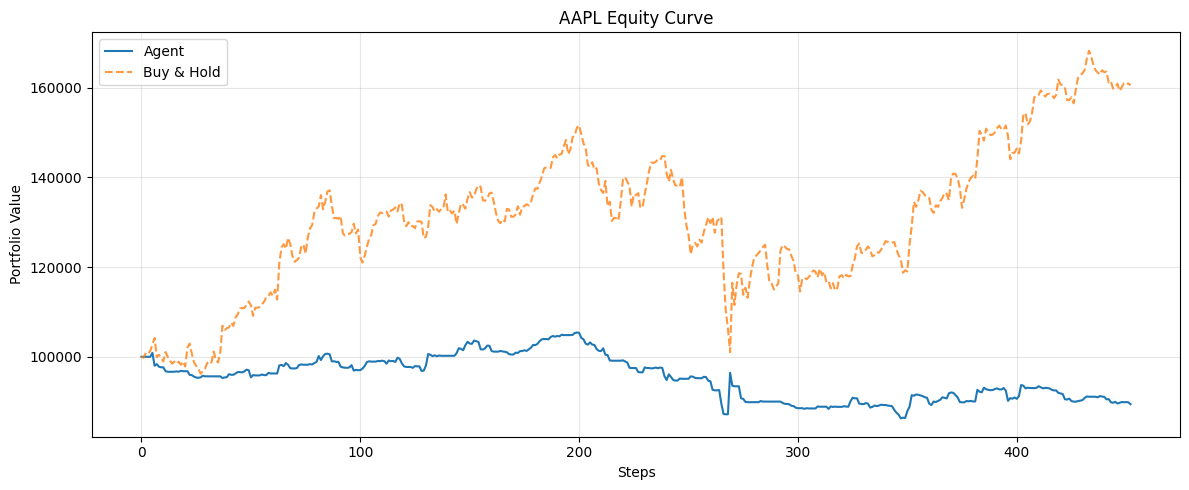

AMD
------------------------------------------------------------
Total Return: -22.7331%
Win Rate:     21.90%
Final Value:  77266.867188

Action Distribution:
  ALLOC_0    Count:  236 |  52.21%
  ALLOC_35   Count:  118 |  26.11%
  ALLOC_70   Count:   98 |  21.68%


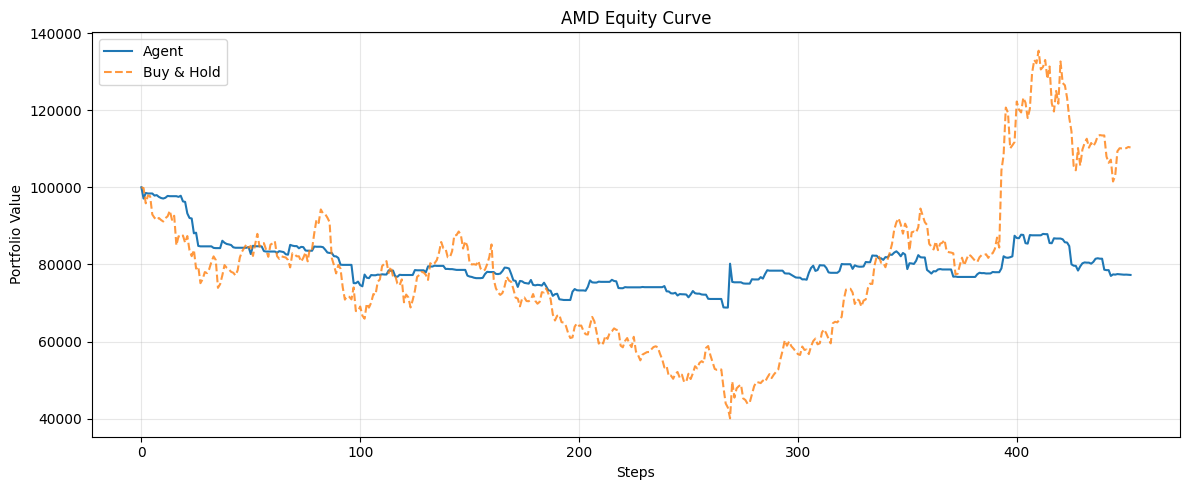

AMZN
------------------------------------------------------------
Total Return: -29.6533%
Win Rate:     24.34%
Final Value:  70346.671875

Action Distribution:
  ALLOC_0    Count:  219 |  48.45%
  ALLOC_35   Count:  114 |  25.22%
  ALLOC_70   Count:  119 |  26.33%


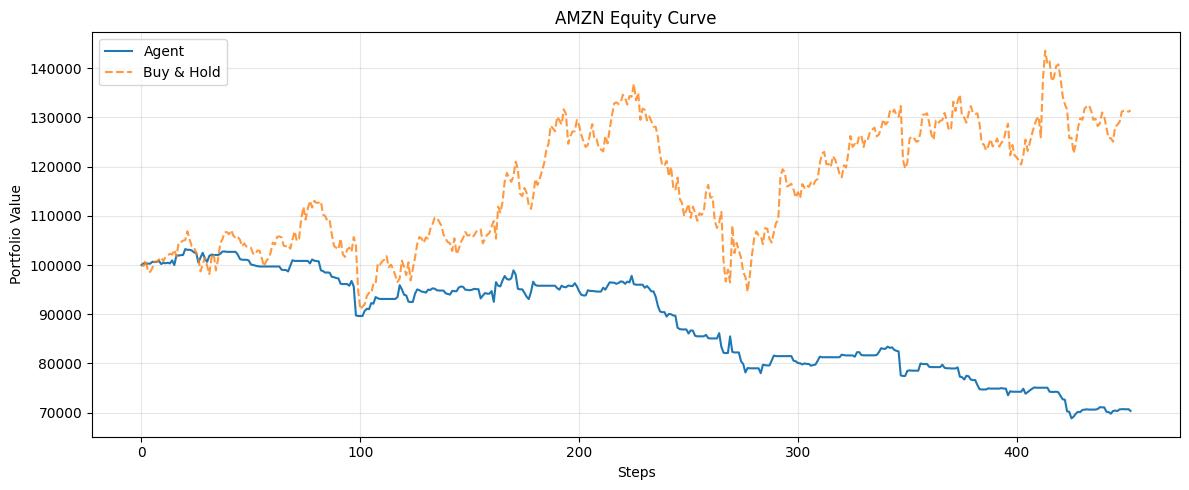

CSCO
------------------------------------------------------------
Total Return: -6.5984%
Win Rate:     27.88%
Final Value:  93401.601562

Action Distribution:
  ALLOC_0    Count:  175 |  38.72%
  ALLOC_35   Count:  133 |  29.42%
  ALLOC_70   Count:  144 |  31.86%


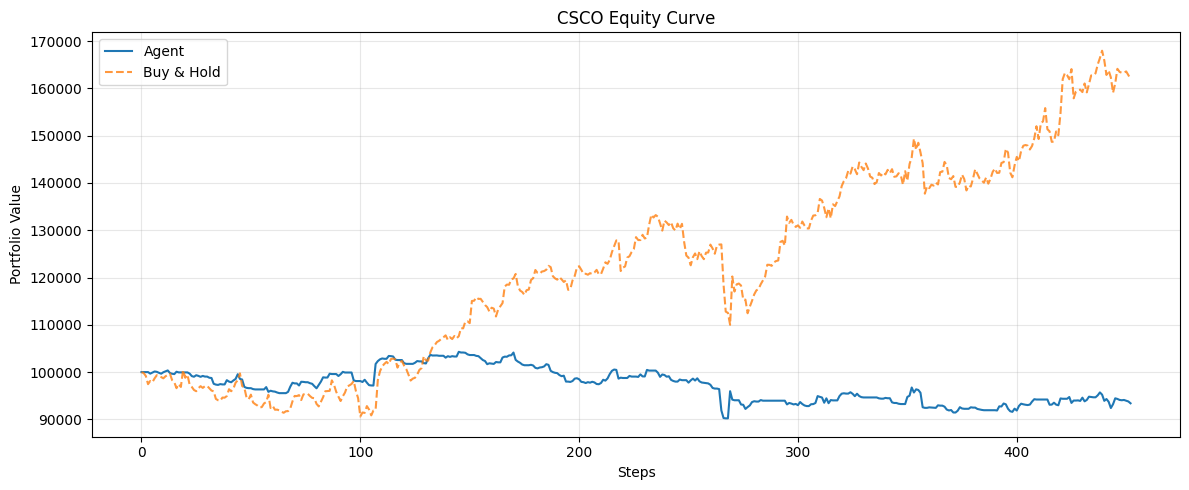

GOOGL
------------------------------------------------------------
Total Return: 1.7941%
Win Rate:     27.43%
Final Value:  101794.140625

Action Distribution:
  ALLOC_0    Count:  207 |  45.80%
  ALLOC_35   Count:  119 |  26.33%
  ALLOC_70   Count:  126 |  27.88%


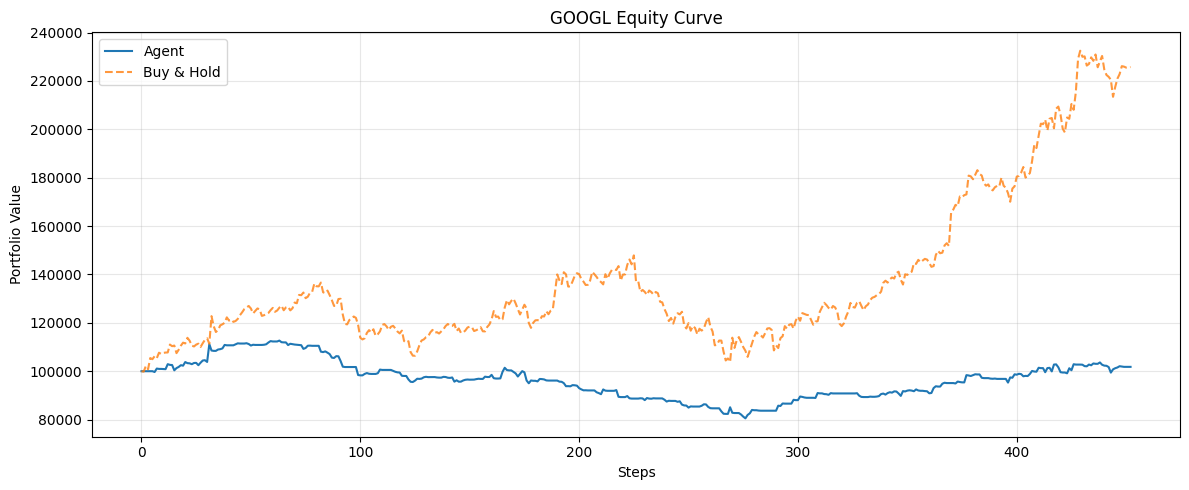

INTC
------------------------------------------------------------
Total Return: 66.6388%
Win Rate:     21.90%
Final Value:  166638.843750

Action Distribution:
  ALLOC_0    Count:  260 |  57.52%
  ALLOC_35   Count:  102 |  22.57%
  ALLOC_70   Count:   90 |  19.91%


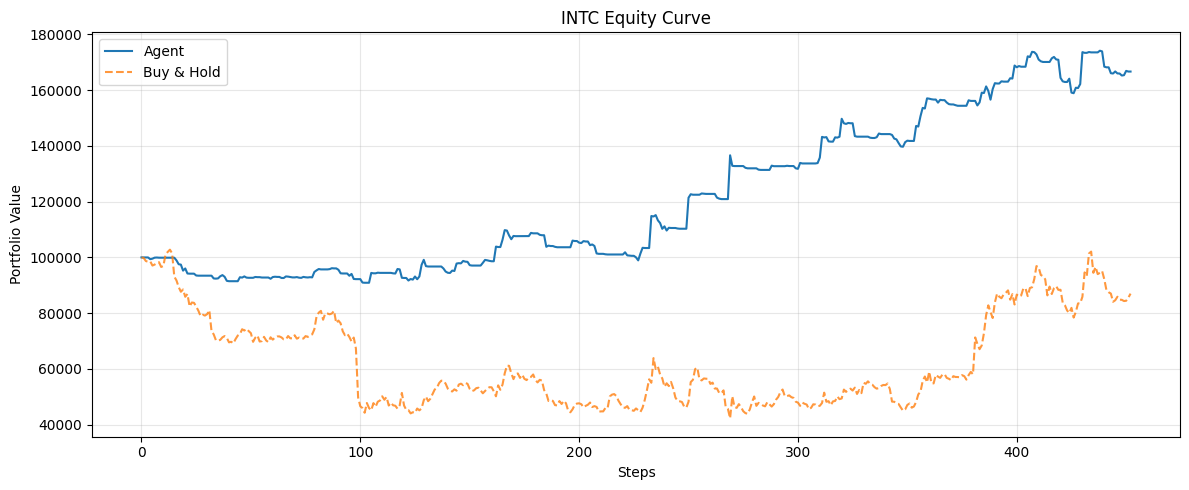

META
------------------------------------------------------------
Total Return: -25.3674%
Win Rate:     23.01%
Final Value:  74632.585938

Action Distribution:
  ALLOC_0    Count:  218 |  48.23%
  ALLOC_35   Count:  127 |  28.10%
  ALLOC_70   Count:  107 |  23.67%


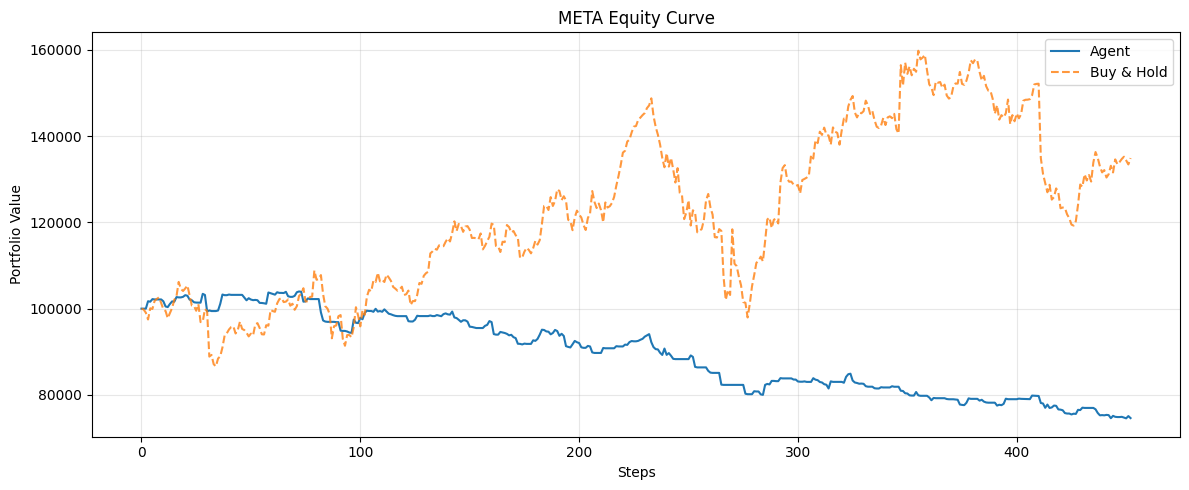

MSFT
------------------------------------------------------------
Total Return: -13.3176%
Win Rate:     26.77%
Final Value:  86682.375000

Action Distribution:
  ALLOC_0    Count:  204 |  45.13%
  ALLOC_35   Count:  154 |  34.07%
  ALLOC_70   Count:   94 |  20.80%


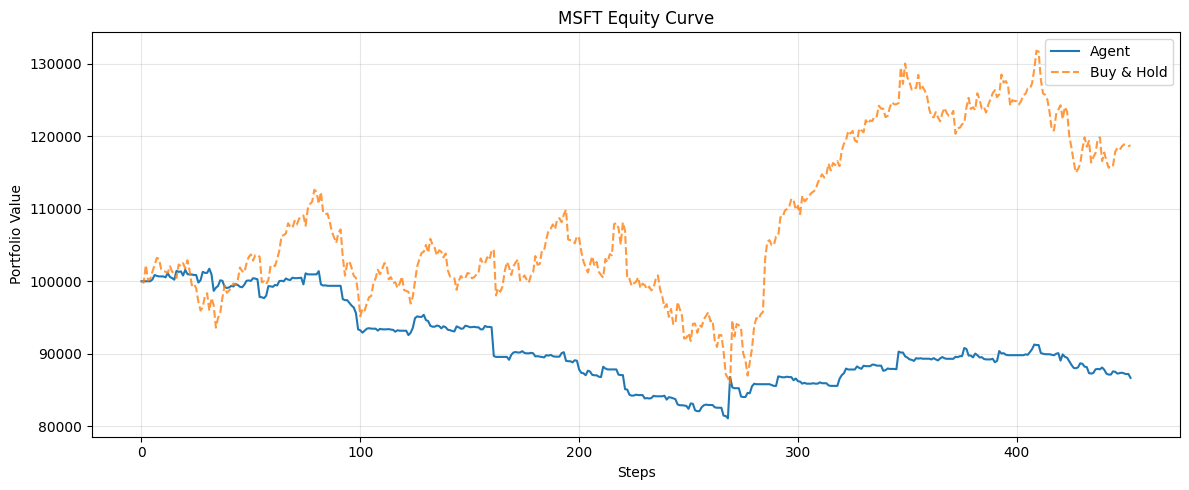

NVDA
------------------------------------------------------------
Total Return: 6.0112%
Win Rate:     25.22%
Final Value:  106011.156250

Action Distribution:
  ALLOC_0    Count:  245 |  54.20%
  ALLOC_35   Count:  110 |  24.34%
  ALLOC_70   Count:   97 |  21.46%


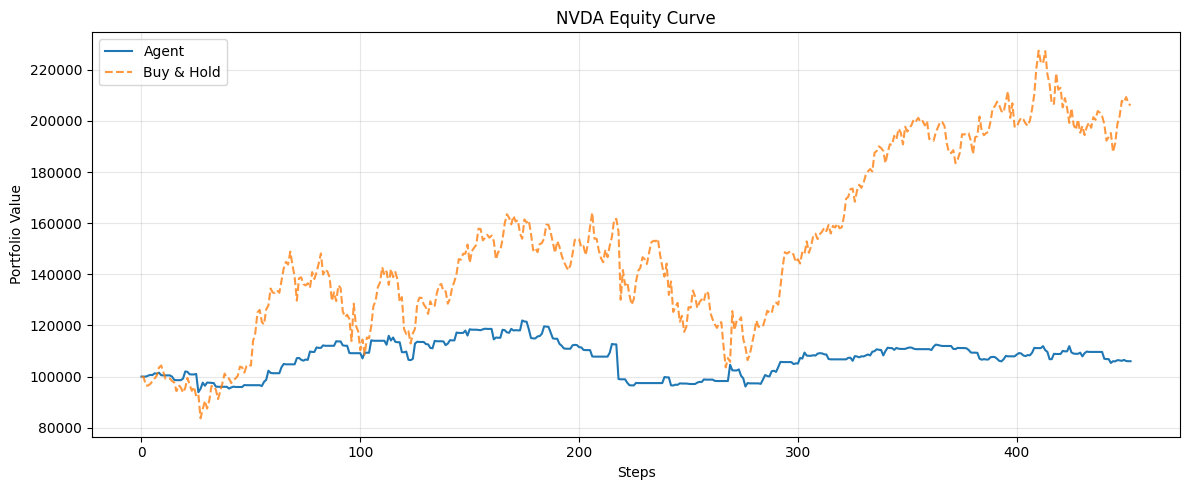

TSLA
------------------------------------------------------------
Total Return: -21.1097%
Win Rate:     19.03%
Final Value:  78890.312500

Action Distribution:
  ALLOC_0    Count:  258 |  57.08%
  ALLOC_35   Count:  102 |  22.57%
  ALLOC_70   Count:   92 |  20.35%


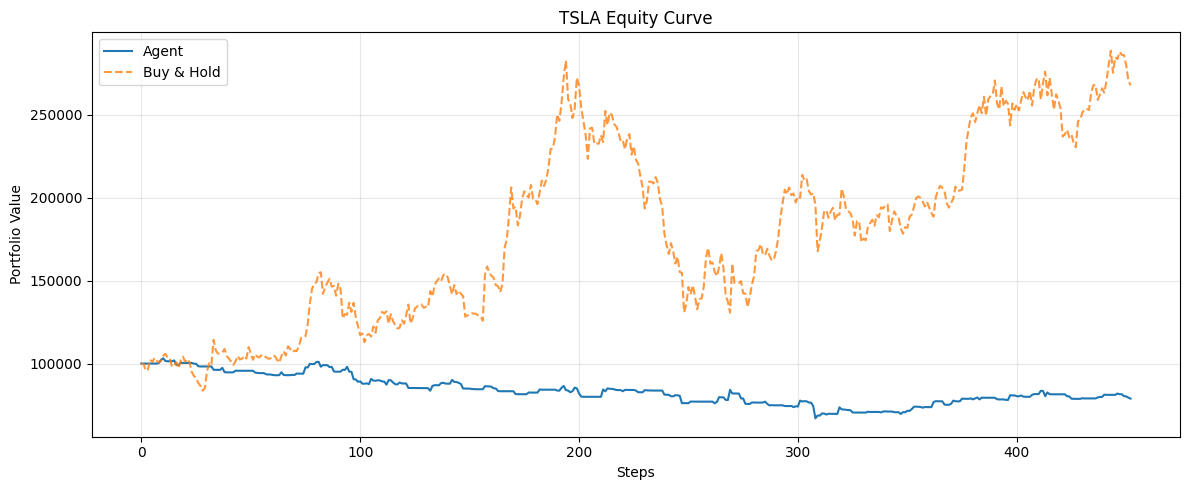

In [8]:
results_best_model = backtest(
    best_model,
    test_states,
    test_prices,
    tickers=tickers,
    steps_per_day=1
)

avg_return = sum(m['Total Return (%)'] for m in results_best_model.values()) / len(results_best_model)
print(f"Average Return: {avg_return:.4f}%")

for i, (ticker, metrics) in enumerate(results_best_model.items()):

    print("="*60)
    print(ticker)
    print("-"*60)

    print(f"Total Return: {metrics['Total Return (%)']:.4f}%")
    print(f"Win Rate:     {metrics['Win Rate (%)']:.2f}%")
    print(f"Final Value:  {metrics['Final Value']:.6f}")

    print("\nAction Distribution:")
    for action_name, stats in metrics["Action Distribution"].items():
        print(
            f"  {action_name:<10} "
            f"Count: {stats['count']:>4} | "
            f"{stats['percentage']:>6.2f}%"
        )

    print("="*60)

    #Buy & Hold Benchmark
    bh_equity = compute_buyhold_equity(test_prices[i])

    # Đảm bảo 2 curve cùng length
    min_len = min(len(metrics["Equity Curve"]), len(bh_equity))

    plot_equity(
        metrics["Equity Curve"][:min_len],
        title=f"{ticker} Equity Curve",
        benchmark=bh_equity[:min_len]
    )